Build, Test, and Visualise the Pytorch FP32 Model

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

This creates synthetic non-linear dataset (a sine wave with noise)

In [14]:
np.random.seed(42)
X_np = np.linspace(-3, 3, 200).astype(np.float32).reshape(-1, 1)
Y_np = np.sin(X_np) + np.random.normal(0, 0.1, X_np.shape).astype(np.float32)

X_torch = torch.from_numpy(X_np)
Y_torch = torch.from_numpy(Y_np)

Small Regression Neural Network

In [15]:
class RegressionNN(nn.Module):
    def __init__(self):
        super(RegressionNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)
    
model = RegressionNN()

Training

In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("Training started...")
for epoch in range(700):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_torch)
    loss = criterion(outputs, Y_torch)
    loss.backward()
    optimizer.step()
    
print(f"Training completed. Final loss: {loss.item():.5f}...\n")



Training started...
Training completed. Final loss: 0.00802...



Test and Visualise pytorch results

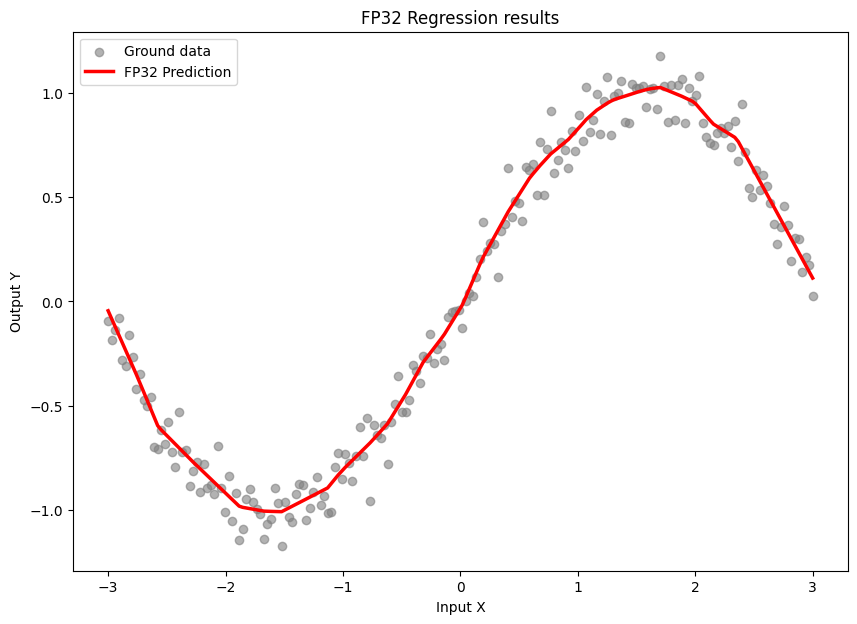

In [17]:
model.eval()
with torch.no_grad():
    predictions_pt = model(X_torch).numpy()

plt.figure(figsize=(10, 7))
plt.scatter(X_np, Y_np, label='Ground data', color='gray', alpha=0.6)
plt.plot(X_np, predictions_pt, label='FP32 Prediction', color='red', linewidth=2.5)
plt.legend()
plt.title("FP32 Regression results")
plt.xlabel("Input X")
plt.ylabel("Output Y")
plt.show()

This script handles multi-step translation and forces tflite converter to quantize to 16 floating points.

In [18]:
import os
import tensorflow as tf

Exporting the Pytorch model to ONNX format

In [19]:
model.eval()
dummy_input = torch.randn(1, 1)

torch.onnx.export(
    model, 
    dummy_input, 
    "regression_model.onnx", 
    input_names=['input_tensor'], 
    output_names=['output_tensor'],
    dynamic_axes={'input_tensor': {0: 'batch_size'}, 'output_tensor': {0: 'batch_size'}})

print("Model exported to ONNX format successfully.")

/tmp/ipykernel_17841/1831760306.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0610 10:56:10.219000 17841 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0610 10:56:10.221000 17841 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0610 10:56:10.222000 17841 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `RegressionNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RegressionNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to ONNX format successfully.


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


Convert ONNX to Tensorflow SavedModel usimg onnx2tf
this will handle complex graph transformations natively

In [24]:
os.system("onnx2tf -i regression_model.onnx -o saved_model_dir")
print("Model converted to TensorFlow format successfully.")

2026-06-10 10:57:50.370134790 [W:onnxruntime:Default, device_discovery.cc:131 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename ""5620e0c7-8062-4dce-aeb7-520c7ef76171"" dit not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+



Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 6              │ 6                │
│ Gemm       │ 3              │ 3                │
│ Relu       │ 2              │ 2                │
│ Model Size │ 17.8KiB        │ 17.8KiB          │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 6              │ 6                │
│ Gemm       │ 3              │ 3                │
│ Relu       │ 2              │ 2                │
│ Model Size │ 17.8KiB        │ 17.8KiB          │
└────────────┴────────────────┴──────────────────┘

S

flatbuffer_direct lowering: 100%|██████████| 5/5 [00:00<00:00, 2375.84it/s]
flatbuffer_direct post-lowering [6/6] topological sort: 100%|██████████| 6/6 [00:00<00:00, 308.20it/s]             
flatbuffer_direct export [4/3] write float16 tflite: 4it [00:00, 444.18it/s]                                  


Use Tflite converter to perform Post-Training FP16 Quantization

In [25]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_dir")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_fp16_model = converter.convert()

OSError: SavedModel file does not exist at: saved_model_dir/{saved_model.pbtxt|saved_model.pb}